In [ ]:
#step 1: import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score




In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Housing (1).csv to Housing (1) (1).csv


In [ ]:
#step 2 : load dataset

df = pd.read_csv("Housing (1).csv")
df.head(4)
df.tail(6)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
539,1855000,2990,2,1,1,no,no,no,no,no,1,no,unfurnished
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [ ]:
#step 3: data set information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
#step 4: dataset cleaning
print("duplicate value count before cleaning:\n",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("duplicate value count after cleaning:",df.duplicated().sum())


duplicate value count before cleaning:
 0
duplicate value count after cleaning: 0


In [ ]:
a=df.select_dtypes(include="object")
b=df.select_dtypes(exclude="object")

print("null value count after cleaning:",df.isnull().sum())

for i in a:
  df[i].fillna(df[i].mode()[0])

for i in b:
  df[i].fillna(df[i].mean())

print("null value count after cleaning:",df.isnull().sum())


null value count after cleaning: price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
null value count after cleaning: price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


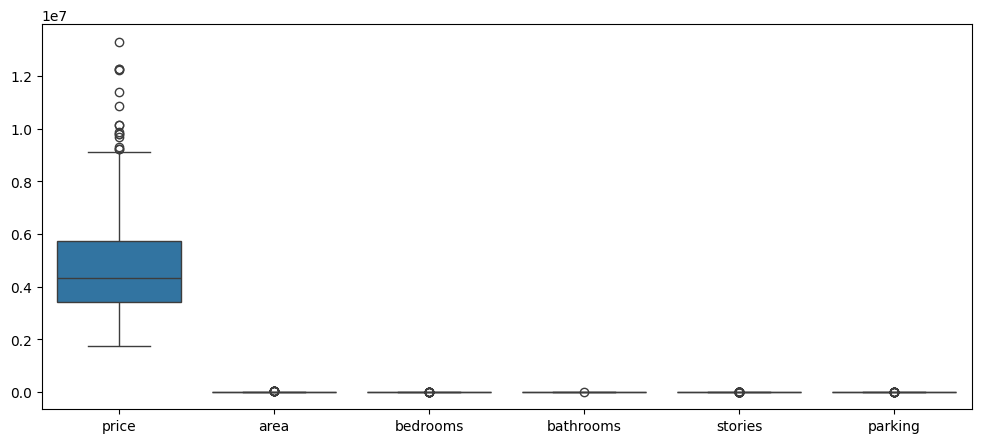

In [ ]:
b=df.select_dtypes(exclude="object")
plt.figure(figsize=(12,5))
sns.boxplot(data=b)
plt.show()

In [ ]:
df_clean=df.copy()
b=df.select_dtypes(exclude="object")
for i in b:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr
  df_clean=df_clean[(df_clean[i]>=lower_bound)&(df_clean[i]<=upper_bound)]
print("before cleaning outliers :",df.shape)
print("after cleaning outliers :",df_clean.shape)

before cleaning outliers : (545, 13)
after cleaning outliers : (463, 13)


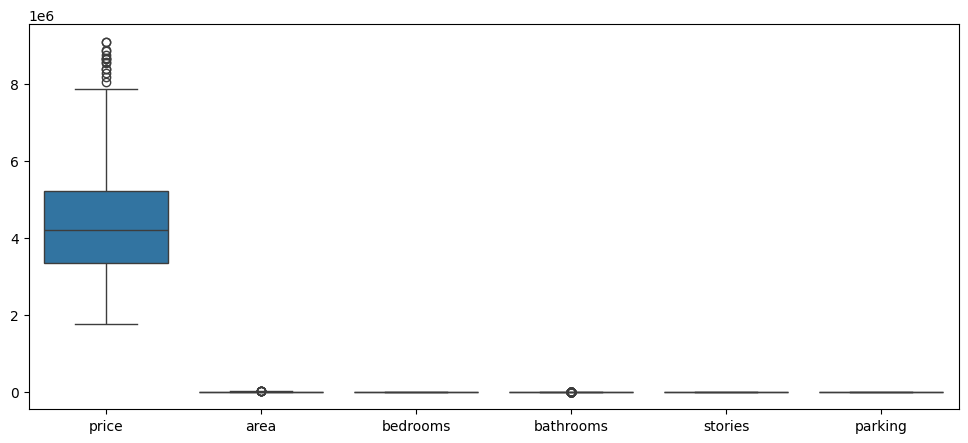

In [ ]:
b=df_clean.select_dtypes(exclude="object")
plt.figure(figsize=(12,5))
sns.boxplot(data=b)
plt.show()

In [ ]:
#step 5
df_clean.rename(columns={"stories":"floors"},inplace=True)
df_clean.head()


,price,area,bedrooms,bathrooms,floors,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,yes,no,yes,no,no,2,no,semi-furnished
16,9100000,6600,4,2,2,yes,yes,yes,no,yes,1,yes,unfurnished
18,8890000,4600,3,2,2,yes,yes,no,no,yes,2,no,furnished
19,8855000,6420,3,2,2,yes,no,no,no,yes,1,yes,semi-furnished
20,8750000,4320,3,1,2,yes,no,yes,yes,no,2,no,semi-furnished


In [ ]:
#step6
df_clean.groupby("furnishingstatus")["price"].mean().reset_index()


,furnishingstatus,price
0,furnished,4.859816e+06
1,semi-furnished,4.628556e+06
2,unfurnished,3.732387e+06


In [ ]:
df_clean.groupby("airconditioning")["price"].mean().reset_index()

,airconditioning,price
0,no,4.007428e+06
1,yes,5.364268e+06


In [ ]:
df_clean.groupby("floors")["price"].mean().reset_index().round()

,floors,price
0,1,4095572.0
1,2,4467758.0
2,3,5471083.0


In [ ]:
df_clean.groupby("bedrooms")["price"].mean().reset_index().round()

,bedrooms,price
0,1,2712500.0
1,2,3564220.0
2,3,4656405.0
3,4,4901900.0


In [ ]:
df_clean["price"].mean()

np.float64(4373745.140388769)

In [ ]:
a=df_clean.query("price>4373745.140388769").shape[0]
print("price above average:",a)
b=df_clean.query("price<4373745.140388769").shape[0]
print("price below average:",b)

price above average: 200
price below average: 263


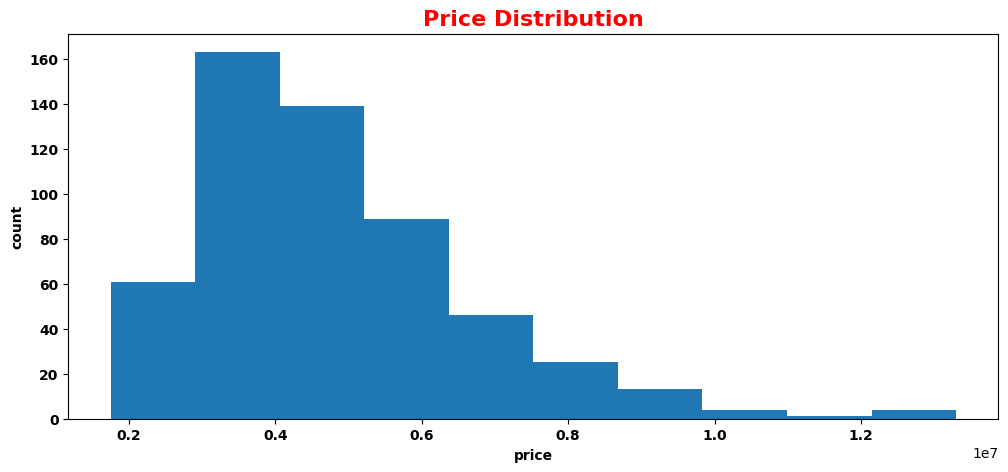

In [ ]:
#step7
plt.figure(figsize=(12,5))
plt.title("Price Distribution",fontweight="bold",fontsize=16,color="red" )
plt.hist(df["price"],bins=10)
plt.xlabel("price",fontweight="bold")
plt.ylabel("count",fontweight="bold")
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")
plt.show()

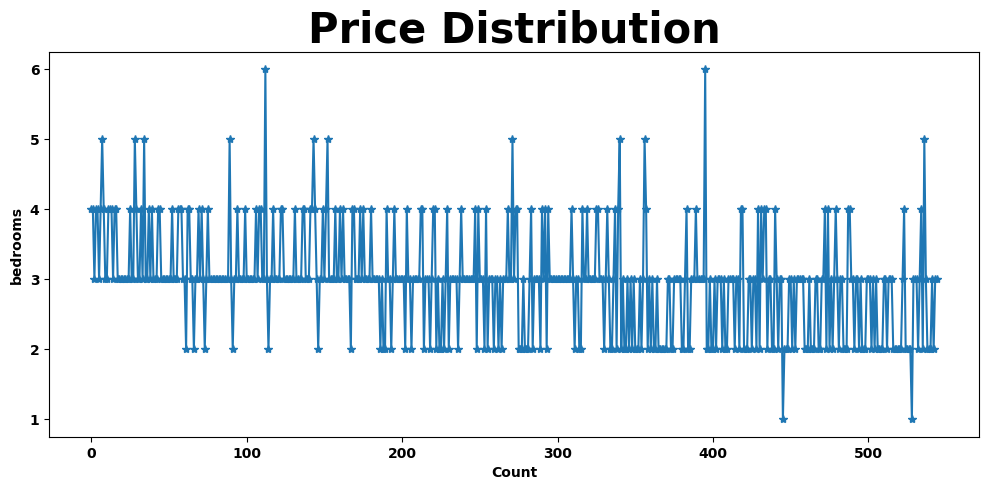

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df["bedrooms"],marker="*")
plt.title("Price Distribution",fontweight="bold",fontsize="30")
plt.xlabel("Count",fontweight="bold")
plt.ylabel("bedrooms",fontweight="bold")
plt.xticks( fontweight="bold")
plt.yticks(fontweight="bold")
plt.show()

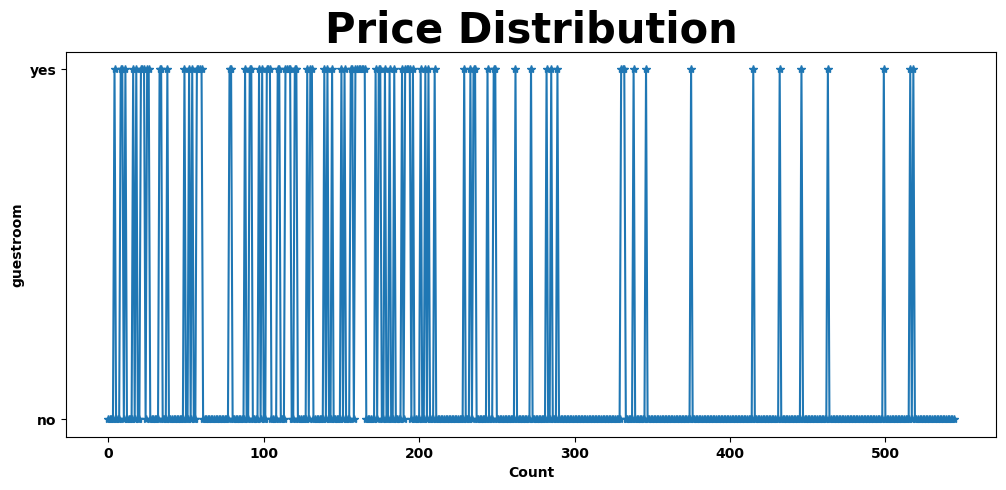

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df["guestroom"],marker="*")
plt.title("Price Distribution",fontweight="bold",fontsize="30")
plt.xlabel("Count",fontweight="bold")
plt.ylabel("guestroom",fontweight="bold")
plt.xticks( fontweight="bold")
plt.yticks(fontweight="bold")
plt.show()

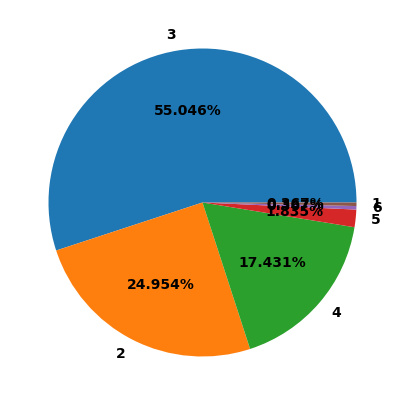

In [ ]:
b=df["bedrooms"].value_counts()
plt.figure(figsize=(12,5))
plt.pie(b.values,labels=b.index,autopct="%1.3f%%",textprops={"fontweight":"bold"})
plt.show()

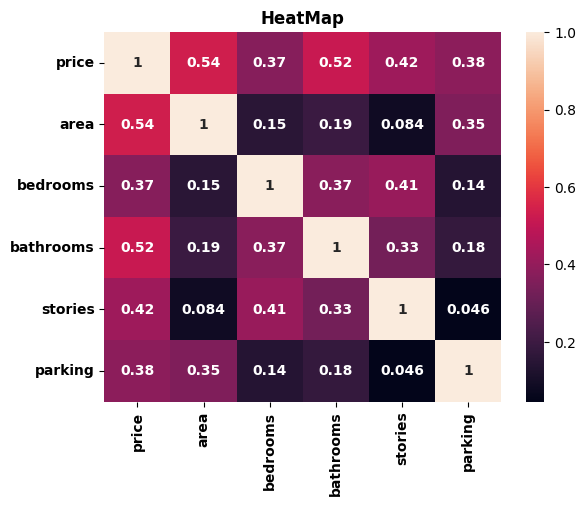

In [ ]:
a=df.select_dtypes(exclude="object")
b=a.corr()
sns.heatmap(b,annot=True,annot_kws={"fontweight":"bold"})
plt.xticks( fontweight="bold")
plt.yticks(fontweight="bold")
plt.title("HeatMap",fontweight="bold")
plt.show()

In [ ]:
#step8
a=df_clean.select_dtypes(include="object")
for i in a:
  le=LabelEncoder()
  df_clean[i]=le.fit_transform(df_clean[i])
df_clean.head()


,price,area,bedrooms,bathrooms,floors,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,1
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,2
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,0
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,1
20,8750000,4320,3,1,2,1,0,1,1,0,2,0,1


In [ ]:
#step9
from sklearn.model_selection import train_test_split
X=df_clean.drop(columns=["price"],axis=1)
y=df_clean["price"]

In [ ]:
X

,area,bedrooms,bathrooms,floors,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,6000,4,1,2,1,0,1,0,0,2,0,1
16,6600,4,2,2,1,1,1,0,1,1,1,2
18,4600,3,2,2,1,1,0,0,1,2,0,0
19,6420,3,2,2,1,0,0,0,1,1,1,1
20,4320,3,1,2,1,0,1,1,0,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,2
541,2400,3,1,1,0,0,0,0,0,0,0,1
542,3620,2,1,1,1,0,0,0,0,0,0,2
543,2910,3,1,1,0,0,0,0,0,0,0,0


In [ ]:
y

,price
15,9100000
16,9100000
18,8890000
19,8855000
20,8750000
...,...
540,1820000
541,1767150
542,1750000
543,1750000


In [ ]:
#step10:spliting
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
#step 11:scaling
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [ ]:
X_train

array([[-0.42740077,  0.21459772, -0.50448858, ..., -0.72205424,
        -0.53777189, -1.48624884],
       [-0.8670762 , -1.31234762,  1.7176635 , ...,  1.91006467,
        -0.53777189, -0.14499989],
       [ 1.06918674,  1.74154307,  1.7176635 , ...,  0.59400522,
        -0.53777189, -0.14499989],
       ...,
       [-0.38230586, -1.31234762, -0.50448858, ...,  0.59400522,
        -0.53777189,  1.19624907],
       [-0.83325502, -1.31234762, -0.50448858, ...,  0.59400522,
        -0.53777189,  1.19624907],
       [ 0.97617848,  0.21459772,  1.7176635 , ..., -0.72205424,
        -0.53777189,  1.19624907]])

In [ ]:
#step 12:train classification modal
modal=LinearRegression()


In [ ]:
#step 13: Fit Modal
modal.fit(X_train,y_train)

LinearRegression()

In [ ]:
#step 14:predict modal
y_pred=modal.predict(X_test)

In [ ]:
#step 15: model accuracy
print(f'r2_score: {r2_score(y_test,y_pred):.2f}')

r2_score: 0.60


In [ ]:
modal2=DecisionTreeClassifier()
modal2.fit(X_train,y_train)
y_pred2=modal2.predict(X_test)
print(f"r2_score: {r2_score(y_test,y_pred):.2f}")

r2_score: 0.60


In [ ]:
modal3=RandomForestClassifier()
modal3.fit(X_train,y_train)
y_pred3=modal3.predict(X_test)
print(f'r2_score: {r2_score(y_test,y_pred):.2f}')


r2_score: 0.60
